In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# get staion locations
station_location = pd.read_excel("./data/weather_station_location.xlsx", sheet_name=1)
station_location

,pfx,纬度,经度
0,hko,22.301944,114.174167
1,hka,22.309444,113.921944
2,sha,22.402500,114.210000
3,lfs,22.468889,113.983611
4,tkl,22.528611,114.156667
5,tms,22.410556,114.124444
6,hks,22.247778,114.173611
7,wgl,22.182222,114.303333
8,gi,22.285000,114.112778
9,jkb,22.315833,114.255556


In [3]:
# domain range
lat_min, lat_max, lon_min, lon_max = (22.139, 22.562, 113.824, 114.417)

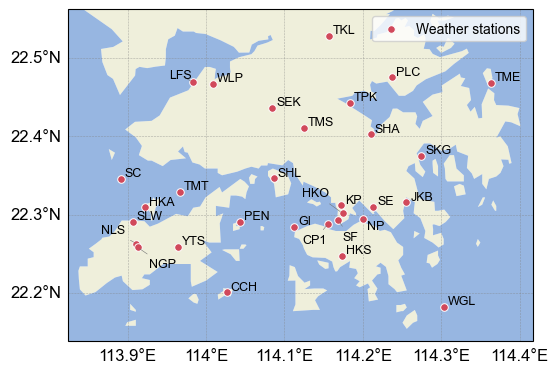

In [4]:
# plot weather station locations
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 12

fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND.with_scale("10m"))
ax.add_feature(cfeature.OCEAN.with_scale("10m"))
# ax.add_feature(cfeature.COASTLINE.with_scale("10m"), linewidth=0.8)
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.4, color="gray", alpha=0.6)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12, "family": "Arial"}
gl.ylabel_style = {"size": 12, "family": "Arial"}

ax.scatter(
    station_location["经度"],
    station_location["纬度"],
    s=30,
    color="#d1495b",
    edgecolor="white",
    linewidth=0.7,
    transform=ccrs.PlateCarree(),
    zorder=3,
    label="Weather stations",
)

custom_offsets = {
    "NLS": (-8, 5),
    "NGP": (8, -8),
    "HKO": (-10, 10),
    "LFS": (-1, 1),
    "NP": (3, -1),
    "CP1": (-1, -8),
    "SF": (3, -8),
}

for _, row in station_location.iterrows():
    station_name = str(row["pfx"]).upper()

    if station_name in custom_offsets:
        offset_x, offset_y = custom_offsets[station_name]
        ha = "left" if offset_x >= 0 else "right"
        va = "bottom" if offset_y >= 0 else "top"
        ax.annotate(
            station_name,
            xy=(row["经度"], row["纬度"]),
            xytext=(offset_x, offset_y),
            textcoords="offset points",
            ha=ha,
            va=va,
            fontsize=9,
            fontfamily="Arial",
            arrowprops={"arrowstyle": "-", "color": "0.45", "lw": 0.4},
            transform=ccrs.PlateCarree(),
            zorder=4,
        )
    else:
        ax.text(
            row["经度"] + 0.005,
            row["纬度"] + 0.003,
            station_name,
            fontsize=9,
            fontfamily="Arial",
            transform=ccrs.PlateCarree(),
            zorder=4,
        )

ax.legend(loc="upper right", prop={"family": "Arial", "size": 10})

plt.savefig('weather_stations.tif', dpi=600, bbox_inches='tight')
plt.show()